# Bank Loan Default Risk — Fundamentals of Data Science Mini Project

**Team:** Sri Sai Raj , Srinivash , Supriya , Thirumurugan , Yuvan |
 **Subject:** Fundamentals of Data Science



## 0. Setup



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset (place the CSV in the same folder as this notebook, or update the path)
df = pd.read_csv('Loan_default_Dataset.csv')

print("Shape:", df.shape)
df.head()

Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


### A quick note 

`Status` is the target column: `1` = the customer defaulted, `0` = they didn't. About 24.6% of customers defaulted.

Several columns have missing values — most importantly for this project, `rate_of_interest` is missing for ~36,439 rows (~24.5%).  For tasks 7–10 below, we drop rows where `rate_of_interest` or `Credit_Score` is missing, which still leaves over 112,000 rows — more than enough.

## 1. NumPy Arrays

**Why:** NumPy arrays are the base data structure for numerical work in Python — faster and more memory-efficient than plain Python lists, and they support vectorized math (like `.sum()`) directly.

In [2]:
# Convert loan_amount column into a NumPy array
loan_amount_arr = np.array(df['loan_amount'])
print("Type:", type(loan_amount_arr))
print("First 5 values:", loan_amount_arr[:5])

# Total loan amount disbursed
total_disbursed = loan_amount_arr.sum()
print(f"Total loan amount disbursed: {total_disbursed:,.0f}")

Type: <class 'numpy.ndarray'>
First 5 values: [116500 206500 406500 456500 696500]
Total loan amount disbursed: 49,227,275,000


## 2. Pandas DataFrames

**Why:** Filtering with boolean conditions is the core Pandas skill — it's how you isolate the subgroup you actually care about (here: defaulters) out of the full dataset.

In [3]:
# Filter the dataset to show Credit_Score for customers who defaulted (Status = 1)
defaulted_credit_scores = df[df['Status'] == 1]['Credit_Score']

print("Number of defaulted customers:", len(defaulted_credit_scores))
defaulted_credit_scores.head(10)

Number of defaulted customers: 36639


0     758
1     552
10    723
12    884
15    685
16    846
17    534
22    692
26    518
38    780
Name: Credit_Score, dtype: int64

## 3. Matplotlib Plots

**Why:** A bar chart makes group comparisons visual and instant — useful here to check, at a glance, whether defaulters tend to have lower credit scores than non-defaulters (spoiler: in this dataset they don't, by much — see the note after the chart).

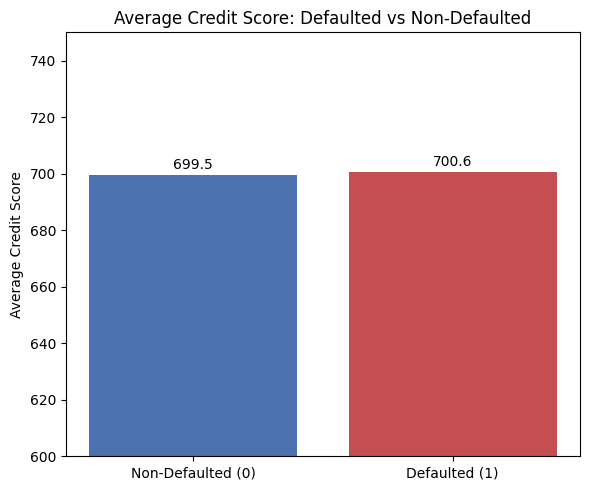

Status
0    699.523793
1    700.600344
Name: Credit_Score, dtype: float64


In [4]:
avg_credit_by_status = df.groupby('Status')['Credit_Score'].mean()

plt.figure(figsize=(6, 5))
plt.bar(['Non-Defaulted (0)', 'Defaulted (1)'], avg_credit_by_status.values,
        color=['#4C72B0', '#C44E52'])
plt.ylabel('Average Credit Score')
plt.title('Average Credit Score: Defaulted vs Non-Defaulted')
for i, v in enumerate(avg_credit_by_status.values):
    plt.text(i, v + 2, f"{v:.1f}", ha='center')
plt.ylim(600, 750)
plt.tight_layout()
plt.savefig('task3_bar_chart.png', dpi=150)
plt.show()

print(avg_credit_by_status)

> **Insight worth saying out loud in your presentation:** the average Credit_Score is almost identical for defaulters (≈700.6) and non-defaulters (≈699.5) — a gap of about 1 point. This is a genuine, useful finding: it means Credit_Score alone is a weak predictor of default *in this specific dataset*, which is exactly the kind of thing a real data scientist reports rather than hides. Don't force a "big difference" narrative that the data doesn't support.

## 4. Frequency Distributions

**Why:** Frequency distributions tell you the shape of a categorical column — which categories dominate, which are rare. Useful before any modeling, so you know if a category is too small to be reliable.

loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64


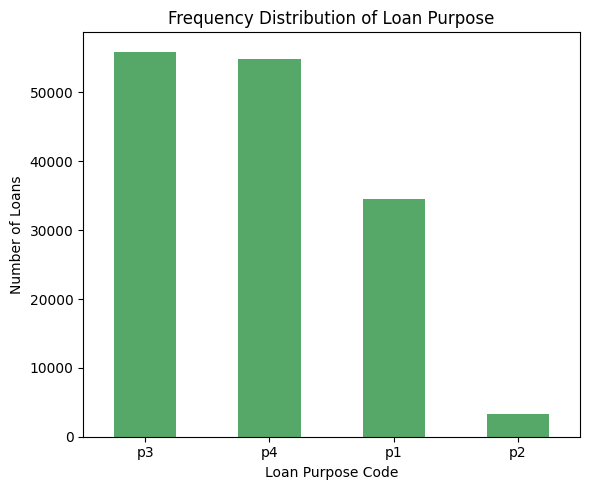

In [5]:
loan_purpose_freq = df['loan_purpose'].value_counts()
print(loan_purpose_freq)

plt.figure(figsize=(6, 5))
loan_purpose_freq.plot(kind='bar', color='#55A868')
plt.xlabel('Loan Purpose Code')
plt.ylabel('Number of Loans')
plt.title('Frequency Distribution of Loan Purpose')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('task4_loan_purpose_freq.png', dpi=150)
plt.show()

*Note: the dataset codes purposes as p1–p4 rather than plain text labels like "Home"/"Car"/"Business" — if your faculty wants the plain labels, ask her for the code-to-label mapping; otherwise present it with the codes as-is and mention this in your report.*

## 5. Averages

**Why:** Mean and median together tell you about skew. If they're far apart, the distribution has outliers pulling the mean away from the "typical" value.

In [6]:
mean_roi = df['rate_of_interest'].mean()
median_roi = df['rate_of_interest'].median()

print(f"Mean rate_of_interest:   {mean_roi:.4f}")
print(f"Median rate_of_interest: {median_roi:.4f}")
print(f"Difference: {abs(mean_roi - median_roi):.4f} — mean and median are very close, so this column isn't heavily skewed.")

Mean rate_of_interest:   4.0455
Median rate_of_interest: 3.9900
Difference: 0.0555 — mean and median are very close, so this column isn't heavily skewed.


## 6. Variability

**Why:** Standard deviation tells you how spread out the values are around the mean — low spread means most customers cluster near the average, high spread means wide variation.

In [7]:
std_credit_score = df['Credit_Score'].std()
print(f"Standard deviation of Credit_Score: {std_credit_score:.4f}")
print(f"For context, Credit_Score ranges from {df['Credit_Score'].min()} to {df['Credit_Score'].max()}.")

Standard deviation of Credit_Score: 115.8759
For context, Credit_Score ranges from 500 to 900.


## 7. Normal Curves

**Why:** Overlaying a normal curve on a histogram lets you visually check whether a variable is approximately normally distributed — this matters because many statistical methods (like the correlation/regression you'll do next) assume roughly normal data.

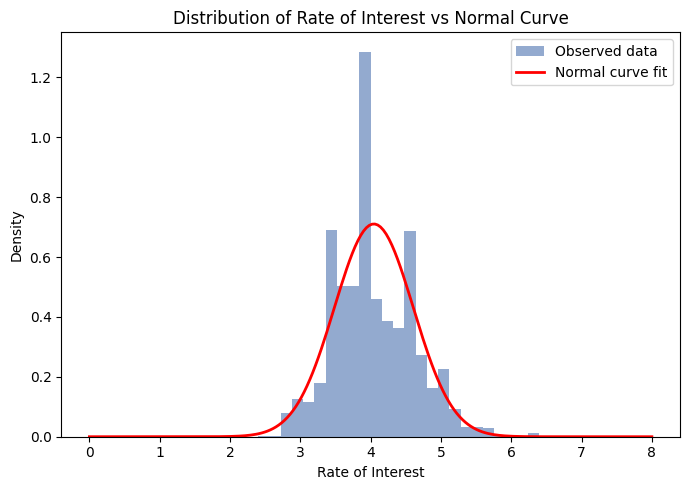

In [8]:
roi_clean = df['rate_of_interest'].dropna()

plt.figure(figsize=(7, 5))
plt.hist(roi_clean, bins=50, density=True, alpha=0.6, color='#4C72B0', label='Observed data')

mu, sigma = roi_clean.mean(), roi_clean.std()
x = np.linspace(roi_clean.min(), roi_clean.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal curve fit')

plt.xlabel('Rate of Interest')
plt.ylabel('Density')
plt.title('Distribution of Rate of Interest vs Normal Curve')
plt.legend()
plt.tight_layout()
plt.savefig('task7_histogram_normal.png', dpi=150)
plt.show()

## 8. Correlation & Scatter Plots

**Why:** A scatter plot is the fastest way to *see* whether two numeric variables move together before you compute anything formal.

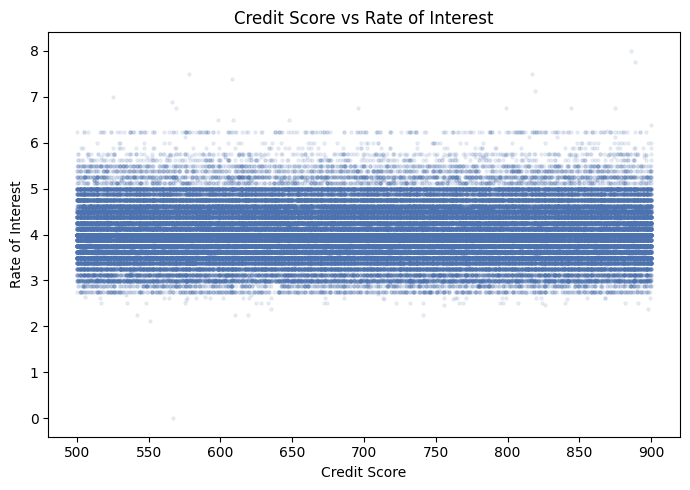

In [9]:
sub = df[['Credit_Score', 'rate_of_interest']].dropna()

plt.figure(figsize=(7, 5))
plt.scatter(sub['Credit_Score'], sub['rate_of_interest'], alpha=0.1, s=5, color='#4C72B0')
plt.xlabel('Credit Score')
plt.ylabel('Rate of Interest')
plt.title('Credit Score vs Rate of Interest')
plt.tight_layout()
plt.savefig('task8_scatter.png', dpi=150)
plt.show()

## 9. Correlation Coefficient

**Why:** The scatter plot gives an impression; the correlation coefficient gives you a single number (from -1 to +1) that quantifies how strong and in what direction the linear relationship is.

In [10]:
correlation = sub['Credit_Score'].corr(sub['rate_of_interest'])
print(f"Correlation coefficient (Credit_Score vs rate_of_interest): {correlation:.5f}")

Correlation coefficient (Credit_Score vs rate_of_interest): -0.00133


## 10. Regression

**Why:** Linear regression fits the best straight line through the data to predict one variable from another. Given the near-zero correlation above, expect this line to be nearly flat, and expect the model's predictive power (R²) to be very low — that's the correct, expected outcome here, not a bug.

Slope (coefficient): -0.000006
Intercept: 4.0500
R² score: 0.000002  (very low — expected, given the ~0 correlation)


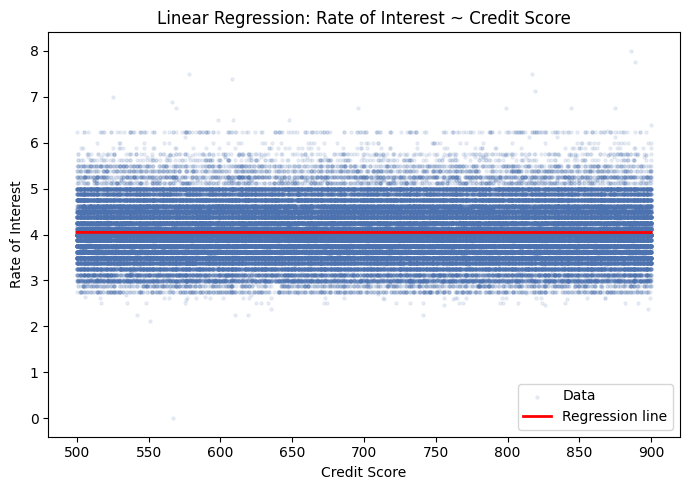


Predicted rate_of_interest for Credit_Score = 750: 4.0451


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = sub[['Credit_Score']].values  # feature must be 2D
y = sub['rate_of_interest'].values

model = LinearRegression()
model.fit(X, y)

print(f"Slope (coefficient): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.4f}")

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² score: {r2:.6f}  (very low — expected, given the ~0 correlation)")

# Plot the regression line over the scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(sub['Credit_Score'], sub['rate_of_interest'], alpha=0.1, s=5, color='#4C72B0', label='Data')
x_line = np.linspace(sub['Credit_Score'].min(), sub['Credit_Score'].max(), 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regression line')
plt.xlabel('Credit Score')
plt.ylabel('Rate of Interest')
plt.title('Linear Regression: Rate of Interest ~ Credit Score')
plt.legend()
plt.tight_layout()
plt.savefig('task10_regression.png', dpi=150)
plt.show()

# Predict the interest rate for a credit score of 750
predicted_rate = model.predict([[750]])
print(f"\nPredicted rate_of_interest for Credit_Score = 750: {predicted_rate[0]:.4f}")

## Summary of findings (for your report / viva)

- Dataset: 148,670 loan records, 34 columns, target `Status` (1 = defaulted, ~24.6% of records).
- Total loan amount disbursed across all records: computed in Task 1.
- Average Credit_Score is nearly identical between defaulters and non-defaulters (~700.6 vs ~699.5) — Credit_Score alone doesn't strongly separate the two groups in this dataset.
- `rate_of_interest` is approximately normally distributed (Task 7).
- Credit_Score and rate_of_interest have essentially **no linear correlation** (~-0.0013), so the regression line is nearly flat and its R² is very low — a genuine, defensible conclusion rather than a modeling failure.
